# Individual Energy-Profile Prediction — curve-approach evaluation

The per-activity **individual curve** prediction benchmark (Baseline, ML DTW,
ML + Ext. Factors, Seq2Seq, …) — the same evaluation as in `results_latex_table`,
extracted on its own.

- Source: `curve_eval_results.parquet` (per-curve records with an **Activity**
  dimension, unlike the `summary_train_test` file the old notebook used).
- Granularity: aggregated **process × activity × sensor**, then across those with
  the **median** (metrics: sMAE, sRMSE, WAPE).
- One table **per process** (all methods) + one **aggregated** table (all
  processes), both as styled tables and LaTeX.
- **Boxplots** of the aggregated per-(process, activity, sensor) values, in the
  same style as the sMAE boxplot in `results_latex_table`.

In [ ]:
# ── Config ────────────────────────────────────────────────────────────────────
import pandas as pd, numpy as np
from pathlib import Path
import matplotlib.pyplot as plt, matplotlib.colors as mcolors
from matplotlib.lines import Line2D
from IPython.display import display, Markdown

EXPERIMENT = 969
SPLIT      = 'TEST'                       # 'TEST' or 'TRAIN'
METRICS    = ['sMAE', 'sRMSE', 'WAPE']    # WAPE is a percentage
BOX_METRIC = 'sMAE'                       # metric for the boxplots
EXCLUDE_APPROACHES = []                   # e.g. ['ML only (no DTW)'] to drop variants
SAVE_LATEX = True

# ── Levelling: two independent ways the approaches are scored on different
#    populations. Both are on by default; turn either off to see the raw
#    behaviour. Section 0 verifies the result and complains if anything is left.

# 1) Curve-length floor, applied to EVERY approach before any table or figure.
# The pipeline does not score the same curves for every approach: the
# *_external ones are evaluated through split_curves_with_prev_activity, which
# keeps curves with >= 5 samples, while every other approach goes through
# split_curves, which keeps >= 2. Curves 2-4 samples long therefore exist for
# six approaches and not for the two prev-activity ones (experiment_964:
# 30,080 vs 26,000 TEST curves), so the raw columns are medians over different
# populations. Filtering here levels them; set to 0 to see the raw behaviour.
MIN_CURVE_POINTS = 5

# 2) Cell coverage. MIN_CURVE_POINTS equalises curve *length*, not WHICH
# (process, activity, sensor) cells an approach is scored on — and the Baseline
# is not scored on the same ones. It is the median curve of a sensor, so it
# exists for every activity, while a learned approach only has a pipeline where
# there was enough training data to fit one. In experiment_968 that left the
# Baseline holding 442 cells / 19,739 TEST curves against 390 / 19,681 for the
# other seven, and its 52 extra cells are the hard ones (median sMAE 3.5, max
# 63.9): the Baseline row was being penalised for activities no other method was
# ever asked to predict. Restricting to the cells every approach owns makes the
# populations identical — same curves, same cells, same non-NaN cells per metric.
LEVEL_CELL_COVERAGE = True

# ── Method names as they should read everywhere (tables, LaTeX, boxplots) ────
# Keys are the raw `Approach` values in curve_eval_results.parquet; anything not
# listed keeps its raw name. Applied right after loading, so every downstream
# table and figure uses these names. NOTE: the raw 'Median per Activity & Sensor'
# must not survive into LaTeX — a bare '&' would be read as a column separator.
METHOD_RENAME = {
    'ML + Ext. Factors':                       'DTW + ML + Ext. Factors',
    'ML DTW':                                  'DTW + ML',
    'Median per Activity & Sensor':            'Median per activity and sensor',
    'DTW + Seq2Seq + Ext. Factors':            'DTW + Seq2Seq + Ext. Factors',
}

results_root = Path('..') / 'results'
runs = sorted([d for d in results_root.iterdir()
               if d.is_dir() and d.name.startswith(f'experiment_{EXPERIMENT}_')])
assert runs, f'No runs for experiment {EXPERIMENT}'
run_dir = runs[-1]
print('Using run:', run_dir.name)

Using run: experiment_968_20260724_180013


In [ ]:
# ── Load + aggregate to (process, activity, sensor, approach) ────────────────
raw = pd.read_parquet(run_dir / 'curve_eval_results.parquet')
raw = raw[raw['Split'] == SPLIT]
if EXCLUDE_APPROACHES:                       # exclusion uses the RAW names
    raw = raw[~raw['Approach'].isin(EXCLUDE_APPROACHES)]

CELL_KEY = ['Process', 'Activity', 'Sensor']
_before = raw.groupby('Approach').size()

# Levelling 1 — curve length (see MIN_CURVE_POINTS).
if MIN_CURVE_POINTS:
    raw = raw[raw['N'] >= MIN_CURVE_POINTS]

# Levelling 2 — cell coverage (see LEVEL_CELL_COVERAGE). Applied AFTER the
# length floor, because dropping short curves can itself empty a cell for one
# approach and not another; intersecting on what survives is what makes the
# populations equal.
if LEVEL_CELL_COVERAGE:
    _cells_of = {a: set(map(tuple, g[CELL_KEY].drop_duplicates().to_numpy()))
                 for a, g in raw.groupby('Approach')}
    _shared = set.intersection(*_cells_of.values()) if _cells_of else set()
    raw = raw[raw[CELL_KEY].apply(tuple, axis=1).isin(_shared)]
    _own_only = {a: len(c - _shared) for a, c in _cells_of.items() if c - _shared}
    print(f'Cell coverage levelled to the {len(_shared)} (process, activity, sensor) '
          f'cells every approach is scored on')
    for _a, _n in sorted(_own_only.items()):
        print(f'  {_a}: dropped {_n} cells no other approach has')

_after = raw.groupby('Approach').size()
_levelling = pd.DataFrame({'curves_raw': _before, 'curves_used': _after}).fillna(0).astype(int)
_levelling['dropped'] = _levelling['curves_raw'] - _levelling['curves_used']
display(Markdown(
    f'**Population levelled** — curves with $\\geq$ {MIN_CURVE_POINTS} samples'
    + (', on the (process, activity, sensor) cells shared by every approach'
       if LEVEL_CELL_COVERAGE else '')))
display(_levelling)
if _levelling['curves_used'].nunique() > 1:
    print('⚠️ curve counts still differ across approaches after levelling — '
          'the comparison is not like-for-like.')

raw['Approach'] = raw['Approach'].replace(METHOD_RENAME)   # display names from here on
print(f'{len(raw):,} per-curve rows | approaches: {raw["Approach"].nunique()} | '
      f'processes: {sorted(raw["Process"].unique())}')
print('methods:', sorted(raw['Approach'].unique()))

# Stage 1: one value per (process, activity, sensor, approach) = median over its curves
_CELL_GROUP = ['Process', 'Activity', 'Sensor', 'Approach']
combo = raw.groupby(_CELL_GROUP)[METRICS].median().reset_index()

# The same collapse under the MEAN, for the mean-aggregated table in section 1.
# Kept as its own frame rather than re-aggregating `combo`: a mean OF medians is
# neither statistic, so the two tables are each internally consistent — 'combo'
# is median all the way up, 'combo_mean' is mean all the way up. Everything else
# in this notebook (counts, per-process tables, boxplots) stays on 'combo'.
combo_mean = raw.groupby(_CELL_GROUP)[METRICS].mean().reset_index()

print('per (process, activity, sensor, approach) rows:', len(combo))

In [ ]:
# ── Table helpers (bold best per column; lower = better) ─────────────────────
# Row labels come from METHOD_RENAME, which is already applied to the data in the
# load cell; it is reapplied here so the tables stay correct even if that cell is
# re-run out of order.
# Column headers in the paper table.
PAPER_HDR = {'sMAE': 'sMAE', 'sRMSE': 'sRMSE', 'WAPE': r'WAPE (\%)'}
# Widths of the paper float — tweak if the table doesn't fit the column.
PAPER_MINIPAGE = '8.5cm'    # minipage holding caption + tabular
PAPER_FIRSTCOL = '6cm'      # p{} width of the method column
PAPER_NOTEBOX  = '12cm'     # parbox width of the note under the table
PAPER_DECIMALS = 3

def _tex(s):
    # Escape the LaTeX specials that can appear in method / process names.
    return (str(s).replace('\\', r'\textbackslash ').replace('&', r'\&')
                  .replace('_', r'\_').replace('%', r'\%').replace('#', r'\#'))

def _row_label(idx):
    return _tex(METHOD_RENAME.get(idx, idx))

# `how` is the stage-2 statistic: how the per-(process, activity, sensor) cells
# are collapsed into one row per approach. Pass the matching frame — `combo` for
# 'median', `combo_mean` for 'mean' — so the table is that statistic at both
# stages. Named `how` and not `agg` because `agg` is already the variable holding
# the median table in section 1.
def approach_table(df_combo, how='median'):
    t = df_combo.groupby('Approach')[METRICS].agg(how)
    return t.sort_values(BOX_METRIC)          # best (lowest) first

def style_table(t, how='median'):
    return (t.style.format({m: '{:.3f}' for m in t.columns}, na_rep='—')
             .highlight_min(axis=0, props='font-weight:700;background-color:#d6ecff;')
             .set_caption(f'{SPLIT} — {how} over process×activity×sensor; lower = better'))

def _cells(t, dp=3):
    # Formatted strings with the per-column minimum bolded.
    s = pd.DataFrame(index=t.index, columns=t.columns, dtype=object)
    for col in t.columns:
        vals = t[col].dropna(); best = vals.min() if not vals.empty else None
        for idx in t.index:
            v = t.loc[idx, col]
            s.loc[idx, col] = ('' if pd.isna(v) else
                               (r'\textbf{' + f'{v:.{dp}f}' + '}')
                               if (best is not None and abs(v - best) < 1e-6)
                               else f'{v:.{dp}f}')
    return s

def to_latex(t, caption, label):
    s = _cells(t)
    s.index = [_row_label(i) for i in t.index]
    latex = s.to_latex(escape=False, column_format='l|' + '|'.join(['c']*len(t.columns)),
                       caption=caption, label=label, position='H')
    return latex

def to_latex_paper(t, caption, label, note):
    # Paper float: table* + minipage, caption on top, booktabs rules, bold header
    # row, and a \parbox note underneath. Needs booktabs + caption in the preamble.
    s = _cells(t, PAPER_DECIMALS)
    body = '\n'.join(' & '.join([_row_label(idx)] + [s.loc[idx, c] for c in t.columns]) + r' \\'
                     for idx in t.index)
    hdr = ' & '.join([r'\textbf{Method}']
                     + [r'\textbf{' + PAPER_HDR.get(c, _tex(c)) + '}' for c in t.columns])
    return '\n'.join([
        r'\begin{table*}[H]',
        r'\centering',
        '',
        rf'\begin{{minipage}}{{{PAPER_MINIPAGE}}}',
        r'\centering',
        '',
        r'\captionsetup{',
        r'    justification=centering,',
        r'    singlelinecheck=false,',
        r'    format=plain',
        r'}',
        '',
        rf'\caption{{{caption}}}',
        rf'\label{{{label}}}',
        '',
        r'\vspace{-0.5em}',
        '',
        rf'\begin{{tabular}}{{p{{{PAPER_FIRSTCOL}}}|' + '|'.join(['c'] * len(t.columns)) + '}',
        r'\toprule',
        hdr + r' \\',
        r'\midrule',
        body,
        r'\bottomrule',
        r'\end{tabular}',
        '',
        r'\vspace{0.5em}',
        '',
        rf'\parbox{{{PAPER_NOTEBOX}}}{{%',
        r'\footnotesize',
        note,
        r'}',
        '',
        r'\end{minipage}',
        '',
        r'\end{table*}',
    ])

## 0 · Evaluation counts per approach

How many evaluations each row of the tables and each box of the plots below is built
from. The medians only compare like with like if every approach is scored on the
**same** (process, activity, sensor) cells; any shortfall is flagged.

In [4]:
# ── Evaluations behind every number below ────────────────────────────────────
# Two populations exist here and they are not the same size:
#   curves -- the per-curve rows of curve_eval_results.parquet (stage-1 input)
#   cells  -- the (process, activity, sensor) medians those curves collapse to.
#             ONE CELL IS ONE UNIT of every median in the tables below and one
#             point in every boxplot.
# The tables only compare like with like if every approach owns the same cells,
# so both counts — plus the non-NaN cells per metric, since a NaN shrinks the
# population of that column alone — are reported before any result.
_KEY = ['Process', 'Activity', 'Sensor']

# Cell-by-cell overlap: equal counts are necessary but not sufficient — two
# approaches can hold the same number of cells without holding the same ones,
# so the shared set is intersected explicitly and reported as its own column.
_sets   = {a: set(map(tuple, g[_KEY].drop_duplicates().to_numpy()))
           for a, g in combo.groupby('Approach')}
_common = set.intersection(*_sets.values()) if _sets else set()
_extra  = {a: len(s - _common) for a, s in _sets.items()}

eval_counts = pd.DataFrame({'curves': raw.groupby('Approach').size(),
                            'cells':  combo.groupby('Approach').size()})
for _m in METRICS:
    eval_counts[f'{_m} cells'] = combo.groupby('Approach')[_m].count()
eval_counts['shared cells']  = pd.Series({a: len(s & _common) for a, s in _sets.items()})
eval_counts['outside shared'] = pd.Series(_extra)   # cells not every approach has
eval_counts = eval_counts.fillna(0).astype(int).sort_index()

display(Markdown('### Evaluation counts per approach — the population of every median below'))
display(eval_counts)

_DIAG   = ['shared cells', 'outside shared']      # diagnostics, not populations
_uneven = [c for c in eval_counts.columns
           if c not in _DIAG and eval_counts[c].nunique() > 1]

if _uneven or any(_extra.values()):
    print('⚠️ approaches are NOT scored on the same population — the medians and '
          'boxplots below are not like-for-like:')
    for c in _uneven:
        hi = eval_counts[c].max()
        print(f'   {c}: max {hi}, others -> ' +
              ', '.join(f'{a}={v}' for a, v in eval_counts[c].items() if v != hi))
    print(f'   (process, activity, sensor) cells shared by every approach: {len(_common)}')
    for a, n in _extra.items():
        if n:
            print(f'   {a}: {n} cells outside that shared set — they enter this '
                  f'approach\'s median and no other')
else:
    print(f'✅ like-for-like: every approach is scored on the same {len(_common)} '
          f'(process, activity, sensor) cells')

### Evaluation counts per approach — the population of every median below

,curves,cells,sMAE cells,sRMSE cells,WAPE cells,shared cells,outside shared
Approach,,,,,,,
Baseline,19681,390,351,351,384,390,0
DTW + ML,19681,390,351,351,384,390,0
DTW + ML + Ext. Factors,19681,390,351,351,384,390,0
DTW + Seq2Seq,19681,390,351,351,384,390,0
DTW + Seq2Seq + Ext. Factors,19681,390,351,351,384,390,0
ML only (no DTW),19681,390,351,351,384,390,0
Median per activity and sensor,19681,390,351,351,384,390,0
Seq2Seq only (no DTW),19681,390,351,351,384,390,0


✅ like-for-like: every approach is scored on the same 390 (process, activity, sensor) cells


## 1 · Aggregated — all processes

In [ ]:
# Two aggregations of the SAME per-curve numbers. Nothing about the models
# changes between them — only how the 390 (process, activity, sensor) cells are
# summarised into one row per method.
#
# Read the ORDER, not the level. The mean table is higher for every method, and
# that is arithmetic rather than a regression: sMAE/sRMSE/WAPE are bounded below
# and have a long right tail, so a handful of badly-predicted cells that the
# median steps over drag every mean up. What is worth looking at is whether the
# RANKING survives. A method that wins only under the median wins on the typical
# cell while losing on the tail; one that wins under both is winning outright.
#
# Note this is a reporting choice and not the models' objective. The curve
# regressors fit ABSOLUTE error (sim_extractor.CURVE_MODEL_LOSS), so they
# estimate the conditional MEDIAN of the curve at each position — which is the
# right estimator for the L1 metrics in both tables. Switching the aggregation
# here does not make them mean-estimators, and does not disadvantage them.
agg_mean = approach_table(combo_mean, how='mean')
display(Markdown('#### Mean aggregation — outlier-sensitive; every cell counts in full'))
display(style_table(agg_mean, how='mean'))

agg = approach_table(combo)
display(Markdown('#### Median aggregation — the reported table (robust to tail cells)'))
display(style_table(agg))

# Where the two disagree — the methods whose standing depends on the choice.
_ranks = pd.DataFrame({
    'median rank': agg[BOX_METRIC].rank().astype(int),
    'mean rank':   agg_mean[BOX_METRIC].rank().astype(int),
    f'{BOX_METRIC} (median)': agg[BOX_METRIC].round(3),
    f'{BOX_METRIC} (mean)':   agg_mean[BOX_METRIC].round(3),
}).sort_values('median rank')
_ranks['moved'] = _ranks['median rank'] - _ranks['mean rank']
display(Markdown(f'#### Rank stability on {BOX_METRIC} '
                 '(`moved` > 0 = ranks worse under the mean, i.e. a heavier tail)'))
display(_ranks)
if (_ranks['moved'] == 0).all():
    print(f'Ranking on {BOX_METRIC} is identical under both aggregations — '
          'the conclusion does not depend on the choice.')
else:
    print('Ranking changes between aggregations for: '
          + ', '.join(_ranks.index[_ranks['moved'] != 0]))

## 2 · Per process (all methods)

In [6]:
per_process = {}
for proc in sorted(combo['Process'].unique()):
    t = approach_table(combo[combo['Process'] == proc])
    per_process[proc] = t
    display(Markdown(f'### {proc}'))
    display(style_table(t))

### process_1

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML,0.757,0.986,7.059
DTW + ML + Ext. Factors,0.760,0.993,7.072
DTW + Seq2Seq + Ext. Factors,0.829,1.018,7.372
DTW + Seq2Seq,0.831,1.024,7.502
Median per activity and sensor,0.840,1.040,7.702
Seq2Seq only (no DTW),0.842,1.025,7.722
ML only (no DTW),0.853,1.037,7.807
Baseline,0.887,1.068,8.154


### process_2

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML,0.377,0.770,47.269
DTW + Seq2Seq,0.378,0.982,74.325
DTW + ML + Ext. Factors,0.388,0.818,49.466
Median per activity and sensor,0.479,0.949,64.294
DTW + Seq2Seq + Ext. Factors,0.559,0.996,85.969
ML only (no DTW),0.670,1.041,84.398
Seq2Seq only (no DTW),0.750,1.012,113.873
Baseline,1.437,1.590,101.432


### process_3

...

,sMAE,sRMSE,WAPE
Approach,,,
Median per activity and sensor,1.974,2.246,7.539
DTW + ML,2.091,2.278,9.661
Baseline,2.161,2.191,6.589
Seq2Seq only (no DTW),2.193,2.421,8.961
ML only (no DTW),2.326,2.353,11.471
DTW + ML + Ext. Factors,2.388,2.505,10.202
DTW + Seq2Seq + Ext. Factors,2.438,2.643,9.433
DTW + Seq2Seq,2.496,2.686,9.007


### process_4_2

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML + Ext. Factors,2.728,2.906,7.498
DTW + Seq2Seq + Ext. Factors,2.857,3.040,7.952
Baseline,2.946,3.135,10.797
DTW + ML,3.335,3.473,11.292
Median per activity and sensor,3.336,3.407,12.662
ML only (no DTW),3.661,3.812,12.538
Seq2Seq only (no DTW),3.744,4.006,11.127
DTW + Seq2Seq,3.774,3.904,11.046


### process_5

,sMAE,sRMSE,WAPE
Approach,,,
DTW + ML,1.487,1.743,5.801
DTW + ML + Ext. Factors,1.511,1.792,6.102
Baseline,1.663,1.934,5.543
DTW + Seq2Seq,1.912,2.102,7.411
ML only (no DTW),1.958,2.168,9.033
Median per activity and sensor,1.981,2.171,6.129
DTW + Seq2Seq + Ext. Factors,2.093,2.294,8.514
Seq2Seq only (no DTW),2.125,2.384,8.522


## 3 · LaTeX

In [7]:
# LaTeX is printed only — no process_metrics_tables/ folder is written.
# The aggregated table is emitted in the paper layout (table* + minipage + note);
# the per-process ones stay in the plain compact layout.

AGG_LABEL = 'tab:energy_results_median_overall'   # label the paper \ref's

tex_agg = to_latex_paper(agg,
    caption='Results for individual profile prediction. ',
    label=AGG_LABEL,
    note=('Standardized median test results per method, across sensors and activities.\n'
          'Lower values are better. Rows are sorted best-to-worst by sMAE.\n'
          r'\textbf{Bold} indicates the best value per metric. The baseline is the '
          'median value of the sensor.'))
print('% ===== ALL PROCESSES ====='); print(tex_agg)

for proc, t in per_process.items():
    tex = to_latex(t,
        caption=(f'Individual energy-profile prediction for {_tex(proc)} ({SPLIT} set). Median over '
                 r'(activity, sensor) of each curve metric; lower is better. '
                 r'\textbf{Bold} = best approach per metric.'),
        label=f'tab:individual_profile_{proc}_{EXPERIMENT}')
    print(f'\n% ===== {proc} ====='); print(tex)


% ===== ALL PROCESSES =====
\begin{table*}[H]
\centering

\begin{minipage}{8.5cm}
\centering

\captionsetup{
    justification=centering,
    singlelinecheck=false,
    format=plain
}

\caption{Results for individual profile prediction. }
\label{tab:energy_results_median_overall}

\vspace{-0.5em}

\begin{tabular}{p{6cm}|c|c|c}
\toprule
\textbf{Method} & \textbf{sMAE} & \textbf{sRMSE} & \textbf{WAPE (\%)} \\
\midrule
DTW + ML & \textbf{1.162} & \textbf{1.398} & \textbf{7.275} \\
DTW + ML + Ext. Factors & 1.164 & 1.400 & 7.367 \\
Median per activity and sensor & 1.293 & 1.522 & 7.820 \\
DTW + Seq2Seq & 1.317 & 1.604 & 7.976 \\
ML only (no DTW) & 1.397 & 1.593 & 8.204 \\
DTW + Seq2Seq + Ext. Factors & 1.400 & 1.665 & 7.904 \\
Baseline & 1.426 & 1.686 & 8.001 \\
Seq2Seq only (no DTW) & 1.507 & 1.739 & 8.192 \\
\bottomrule
\end{tabular}

\vspace{0.5em}

\parbox{12cm}{%
\footnotesize
Standardized median test results per method, across sensors and activities.
Lower values are better. Rows are

## 4 · Boxplot — aggregated per (process, activity, sensor)

Same style as the sMAE boxplot in `results_latex_table`: one box per approach over
all (process, activity, sensor) values, sorted best-at-top, x-axis capped near the
95th percentile.

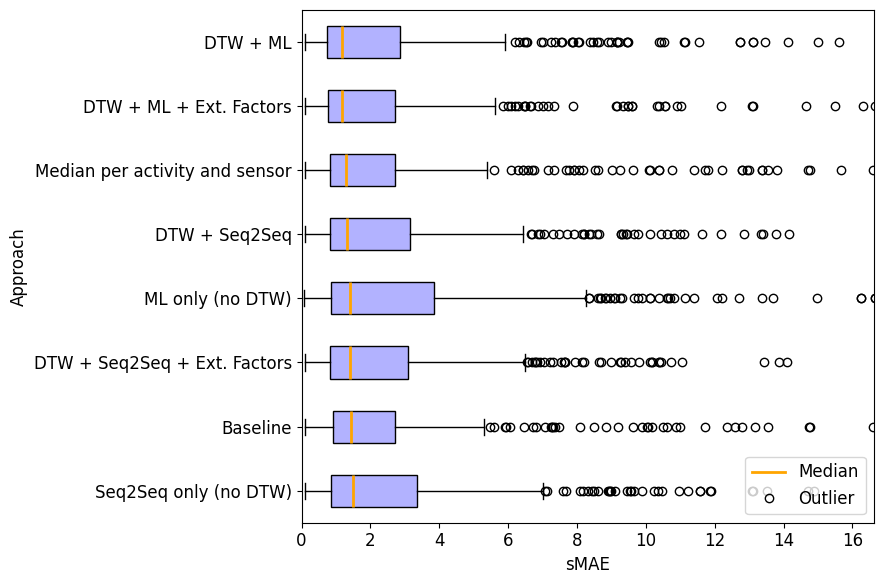

Saved: visuals/individual_profile_sMAE_boxplot.pdf


In [8]:
plt.rcParams.update({'font.size': 12})
df_box = combo[~combo['Approach'].isin(EXCLUDE_APPROACHES)]
box_order = df_box.groupby('Approach')[BOX_METRIC].median().sort_values(ascending=False).index.tolist()
data = [df_box.loc[df_box['Approach'] == a, BOX_METRIC].dropna().values for a in box_order]

fig, ax = plt.subplots(figsize=(9, 6))
bplot = ax.boxplot(data, tick_labels=box_order, showfliers=True, vert=False,
                   patch_artist=True, medianprops=dict(color='orange', linewidth=2))
blue_rgba = mcolors.to_rgba('blue', alpha=0.3)
for patch in bplot['boxes']:
    patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
all_vals = np.concatenate([d for d in data if len(d)])
ax.set_xlim(0, np.percentile(all_vals, 95) * 1.3)
ax.set_xlabel(BOX_METRIC); ax.set_ylabel('Approach')
ax.legend(handles=[Line2D([0],[0],color='orange',lw=2,label='Median'),
                   Line2D([0],[0],marker='o',color='w',markeredgecolor='black',
                          markerfacecolor='none',markersize=6,label='Outlier')], loc='lower right')
fig.tight_layout()
Path('visuals').mkdir(exist_ok=True)
fig.savefig(f'visuals/individual_profile_{BOX_METRIC}_boxplot.pdf', dpi=300, bbox_inches='tight')
plt.show()
print(f'Saved: visuals/individual_profile_{BOX_METRIC}_boxplot.pdf')

### Boxplots for every metric

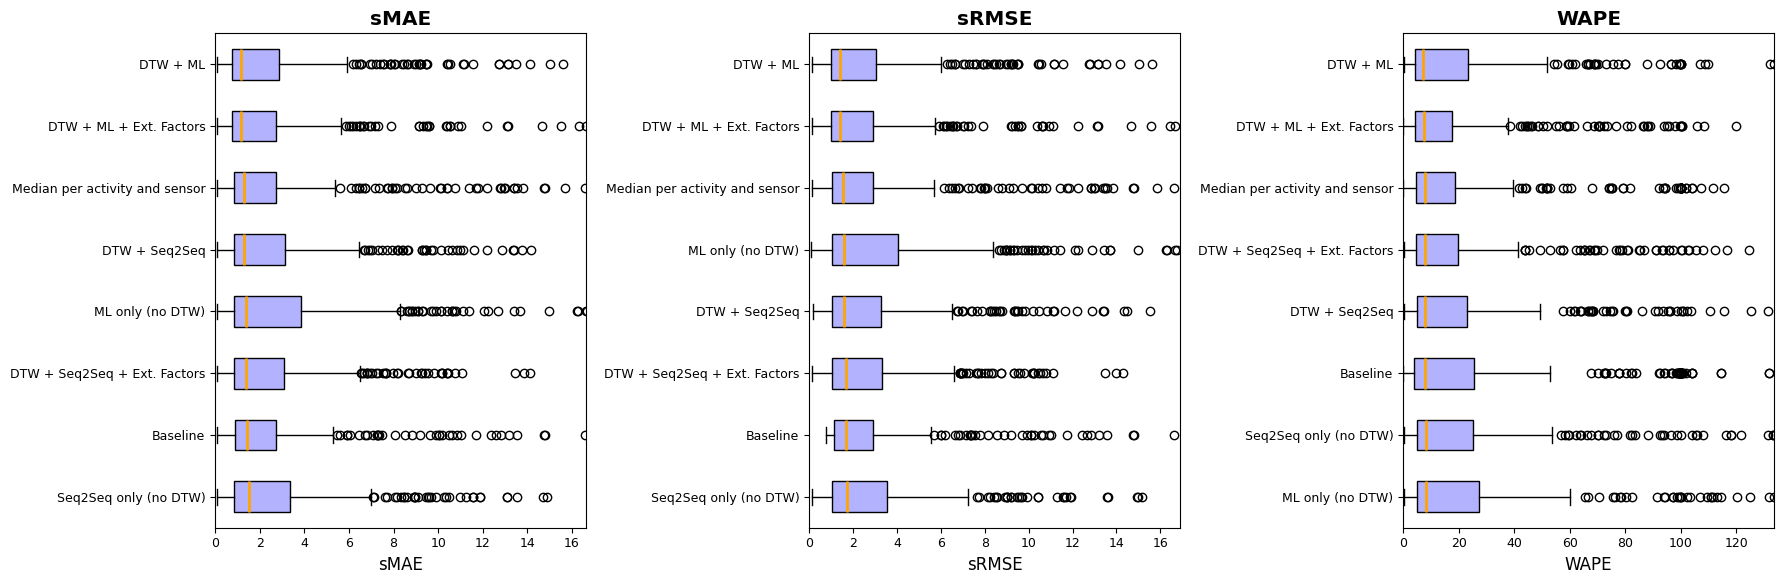

In [9]:
metrics = METRICS
fig, axes = plt.subplots(1, len(metrics), figsize=(6*len(metrics), 6))
axes = np.atleast_1d(axes)
for ax, metric in zip(axes, metrics):
    order = df_box.groupby('Approach')[metric].median().sort_values(ascending=False).index.tolist()
    data = [df_box.loc[df_box['Approach'] == a, metric].dropna().values for a in order]
    bp = ax.boxplot(data, tick_labels=order, showfliers=True, vert=False,
                    patch_artist=True, medianprops=dict(color='orange', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(blue_rgba); patch.set_edgecolor('black')
    av = np.concatenate([d for d in data if len(d)])
    if len(av): ax.set_xlim(0, np.percentile(av, 95) * 1.3)
    ax.set_xlabel(metric); ax.set_title(metric, fontweight='bold')
    ax.tick_params(labelsize=9)
fig.tight_layout()
plt.show()